# General Tasks 1

Importing files [Komponente_K7.csv](data/Logistikverzug/Komponente_K7.csv) and [Logistikverzug_K7.csv](data/Logistikverzug/Logistikverzug_K7.csv) and taking a look at the data and filetypes 


In [1]:
import pandas as pd
from IPython.display import display

# Import Data
komponente_k7 = pd.read_csv("data/Logistikverzug/Komponente_K7.csv", sep=";", index_col=0)
logistikverzug_k7 = pd.read_csv("data/Logistikverzug/Logistikverzug_K7.csv", sep=",", index_col=0)

# Display Data
display(komponente_k7.sort_values(by='IDNummer').reset_index(drop=True).head())
display(logistikverzug_k7.sort_values(by='IDNummer').reset_index(drop=True).head())

,IDNummer,Produktionsdatum,Herstellernummer,Werksnummer,Fehlerhaft
0,K7-113-1132-1,2012-11-12,112,1132,0
1,K7-113-1132-10,2012-11-12,112,1132,0
2,K7-113-1132-100,2012-11-13,112,1132,0
3,K7-113-1132-1000,2012-11-22,112,1132,0
4,K7-113-1132-10000,2013-02-15,112,1132,0


,IDNummer,Wareneingang,Herstellernummer,Werksnummer,Fehlerhaft
0,K7-113-1132-1,2012-11-18,112,1132,0
1,K7-113-1132-10,2012-11-19,112,1132,0
2,K7-113-1132-100,2012-11-18,112,1132,0
3,K7-113-1132-1000,2012-11-30,112,1132,0
4,K7-113-1132-10000,2013-02-22,112,1132,0


## Task 1a)

* merged both datasets on IDNummer, calculated Verzug = Wareneingang − (Produktionsdatum + 1 day), then analyzed the distribution with descriptive statistics.

* mean = 6.08, variance = 1.02, var/mean = 0.17, skewness = 0.57, min = 3, max = 14, 306,490 observations.

**Interpretation:** The delay is discrete (whole days) and slightly right-skewed.

## Task 1b) Interpreting the logistics delay and discussing possible alternatives

* The working day delay is reduced, due to removing the weekends. That would reduce the mean delay time considerably because the mean was at around 6 days before.
* If the warehouse does work on weekends then it would not make sense to remove the weekends
* This calculations does not include german holidays which could be important to assess aswell depending on the warehouse operation days.
* the generalized issue date does shift all dates by one day. Including 'Ausgabedatum' weekdays into weekends and vice versa. Important to be aware of that.




In [2]:
import numpy as np

# Merge DataFrames
logistics_delay = pd.merge(
    komponente_k7[['IDNummer', 'Produktionsdatum', 'Herstellernummer', 'Werksnummer', 'Fehlerhaft']],
    logistikverzug_k7[['IDNummer', 'Wareneingang']],
    on='IDNummer',
    how='inner'
)

# Converting to datetime datatypes
logistics_delay['Produktionsdatum'] = pd.to_datetime(logistics_delay['Produktionsdatum'])
logistics_delay['Wareneingang'] = pd.to_datetime(logistics_delay['Wareneingang'])
display(logistics_delay.dtypes)

# Calculating Ausgabedatum and Verzug column needed for later analysis
logistics_delay['Ausgabedatum'] = logistics_delay['Produktionsdatum'] + pd.Timedelta(days=1)
logistics_delay['Verzug'] = (logistics_delay['Wareneingang'] - logistics_delay['Ausgabedatum']).dt.days
logistics_delay['Verzug_AT'] = np.busday_count(logistics_delay['Ausgabedatum'].values.astype('datetime64[D]'), logistics_delay['Wareneingang'].values.astype('datetime64[D]')) # type: ignore

# Display stats
display(logistics_delay['Verzug'].describe())
mean = logistics_delay["Verzug"].mean()
var  = logistics_delay["Verzug"].var()
print(mean, var, var/mean)
print(logistics_delay["Verzug"].skew(), logistics_delay["Verzug"].kurtosis())
print(logistics_delay["Verzug"].value_counts().sort_index())


IDNummer                       str
Produktionsdatum    datetime64[us]
Herstellernummer             int64
Werksnummer                  int64
Fehlerhaft                   int64
Wareneingang        datetime64[us]
dtype: object

count    306490.000000
mean          6.080437
std           1.012302
min           3.000000
25%           5.000000
50%           6.000000
75%           7.000000
max          14.000000
Name: Verzug, dtype: float64

6.080436555841953 1.0247545510241096 0.16853305541681007
0.5674067497996637 0.6300548717524213
Verzug
3         19
4       8499
5      81657
6     124094
7      67161
8      19973
9       4260
10       690
11       110
12        22
13         4
14         1
Name: count, dtype: int64


## c)  Visualize the distribution with a histogram and density function

* bins is set manually with a dictionary containing min and max values of the Delay.
* It is done through a dictionary to ensure the histogramm is divided into whole numbers. The values are integers.

In [3]:
import plotly.express as px

# Histogram with count
fig = px.histogram(
    logistics_delay, x="Verzug",
    title="Verzug (Anzahl)",
    labels={"Verzug": "Verzug (Kalendertage)"}
)
fig.update_traces(xbins=dict(start=logistics_delay["Verzug"].min(), end=logistics_delay["Verzug"].max(), size=1))
fig.update_layout(title_x=0.5)
fig.show()

# Histogram with density
fig = px.histogram(
    logistics_delay, x="Verzug", histnorm="probability density",
    title="Verzug (Dichte)",
    labels={"Verzug": "Verzug (Kalendertage)"}
)
fig.update_traces(xbins=dict(start=logistics_delay["Verzug"].min(), end=logistics_delay["Verzug"].max(), size=1))
fig.update_layout(title_x=0.5)
fig.show()


## Task 1d)

* Process: features = Verzug, Herstellernummer, Werksnummer, and Produktionsdatum split into day/month/year. IDNummer excluded (unique per row, would be memorized). 
* Stratified shuffle split (5 folds, 30% test) to guarantee defects appear in each test set. 
* DecisionTreeClassifier with max_depth=4 to limit overfitting. Evaluated by confusion matrix, not accuracy.
* Only 6/306,490 components are faulty (0.002%). Always predicting "not faulty" gives 99.998% accuracy.
* Stratification puts 4 defects in training, 2 in test. Four examples are not enough to define a decision boundary.
* Confusion matrix: on all 5 folds the model predicted "not faulty" for every row, missing both test defects each time.
* Conclusion: the method is applicable, but the data does not support a validated model. More defect cases would be needed.

* The tree splits primarily on Tag, a feature with no process-related meaning, which indicates it is fitting noise. Even in nodes containing defective parts, the majority class remains "OK", so no leaf ever predicts a defect.

Index(['IDNummer', 'Produktionsdatum', 'Herstellernummer', 'Werksnummer',
       'Fehlerhaft', 'Wareneingang', 'Ausgabedatum', 'Verzug', 'Verzug_AT'],
      dtype='str')
Fehlerhaft
0    0.99998
1    0.00002
Name: proportion, dtype: float64
Fehlerhaft
0    306484
1         6
Name: count, dtype: int64

--- Split 0: 4 defects in train, 2 in test ---
[[91945     0]
 [    2     0]]

--- Split 1: 4 defects in train, 2 in test ---
[[91945     0]
 [    2     0]]

--- Split 2: 4 defects in train, 2 in test ---
[[91945     0]
 [    2     0]]

--- Split 3: 4 defects in train, 2 in test ---
[[91945     0]
 [    2     0]]

--- Split 4: 4 defects in train, 2 in test ---
[[91945     0]
 [    2     0]]


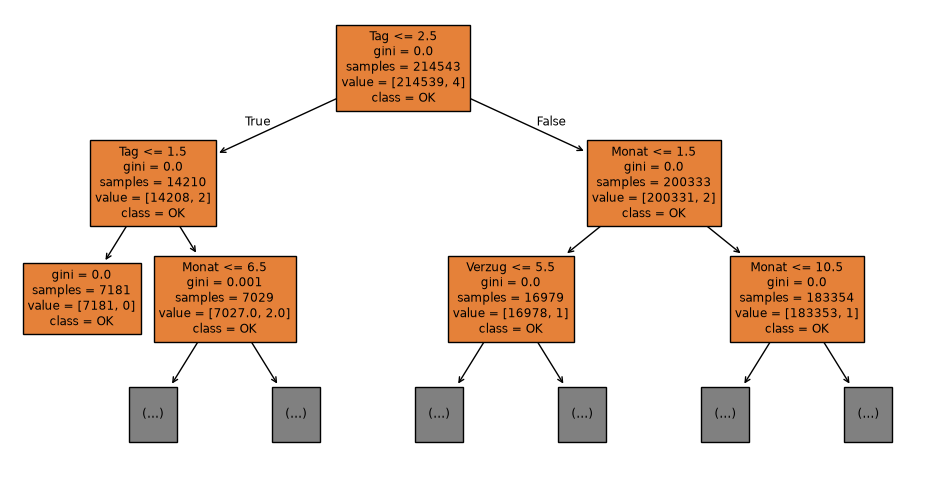

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

print(logistics_delay.columns)
# Analyze amount of faulty components
print(logistics_delay["Fehlerhaft"].value_counts(normalize=True))
print(logistics_delay["Fehlerhaft"].value_counts())

# Deriving new columns for day, month, and year from Produktionsdatum
logistics_delay["Tag"]   = logistics_delay["Produktionsdatum"].dt.day
logistics_delay["Monat"] = logistics_delay["Produktionsdatum"].dt.month
logistics_delay["Jahr"]  = logistics_delay["Produktionsdatum"].dt.year

# Splitting the data into features and target variable
X = logistics_delay[["Verzug", "Herstellernummer", "Werksnummer", "Tag", "Monat", "Jahr"]]
y = logistics_delay["Fehlerhaft"]

# Stratified shuffle split: repeated splits, each preserving the class ratio
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=42)

for i, (train_idx, test_idx) in enumerate(sss.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf = DecisionTreeClassifier(max_depth=4, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"\n--- Split {i}: {y_train.sum()} defects in train, {y_test.sum()} in test ---")
    print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=X.columns, class_names=["OK", "Fehlerhaft"], filled=True, max_depth=2) # type: ignore
plt.show()